<a href="https://colab.research.google.com/github/AD8787/AP-Stats-DS/blob/main/RCDataframeVisualization.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [93]:
#create a data structure that represents the cards that are available for selection
driver_cards = ["Joey Lagano", "Kevin Harvick", "Chase Elliott", "Danica Patrick","Jimmie Johnson"]

In [94]:
'''
1. Randomly select a card
2. Store card in collection, assuming it is not already there
3. Repeat process until your collection is complete (all 5 cards present)
4. count how many pulls were needed in order to complete collection
5. store count somewhere
6. repeat 1-5 many times over (number of trials)
'''
import random

record_num_pulls = []
for i in range(10000):
  #begin single trial
  collection = []
  pulls = 0
  #loop through, selecting a card, until I have all cards
  while len(collection)<5:
    card_selection = random.choice(driver_cards)
    pulls += 1
    if card_selection not in collection:
      collection.append(card_selection)
  #end trial
  #store number of pulls it took to complete selection
  record_num_pulls.append(pulls)


In [95]:
import pandas as pd
import matplotlib.pyplot as plt

In [96]:
#convert the list of pulls from each trial into a dataframe
pulls_df = pd.DataFrame({"pulls":record_num_pulls})
#print the first 10 rows of the df
print(pulls_df.head(10))

   pulls
0      6
1     19
2     21
3     14
4     15
5     12
6      6
7      9
8      8
9      8


In [97]:
frequency_df = pulls_df["pulls"].value_counts().sort_index().reset_index()
print(frequency_df.head())

   pulls  count
0      5    374
1      6    773
2      7    965
3      8   1068
4      9   1047


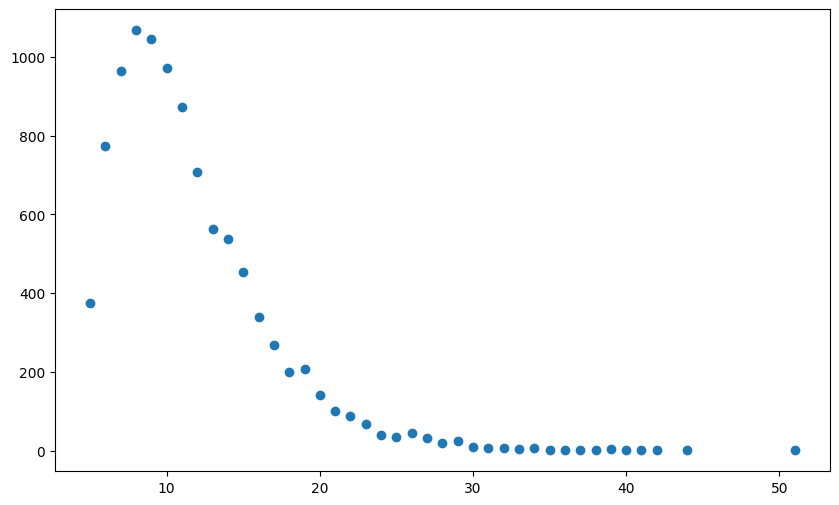

In [98]:
#create visualization of frequency distribution
'''
1. construct a "figure" (creating mathematical "canvas")
2. feed data into appropriate plot (visualization)
3. show the visualization
'''

plt.figure(figsize=(10,6))
plt.scatter(frequency_df["pulls"],frequency_df["count"])
plt.show()

## 🛠️ Your Task: Improving the Visualization
### Instructions:
1. Change the visualization to a "STACKED DOT PLOT"
2. Customize the visualization - set a color, give titles to the axes, etc
3. Repeat, this time for a histogram (a bar graph)

## Your next Task: Answer probability questions regarding the distribution of pulls
### Instructions:
1. Print out the following metrics of your distribution:
  a. average
  b. median
  c. first quartile (25th percentile)
  d. third quartile (75th percentile)
2. Based on your simulation, what is the experimental probability that it takes more than 10 pulls to complete the collection?

---
## 📦 How to Submit Your Work
1. Run all cells in your notebook (**Runtime > Run all**).
2. Go to **File > Print**.
3. Set your printer destination to **Save as PDF**.
4. Check the preview to make sure your code outputs and exit ticket answers are readable.
5. Save the PDF and upload it to [Insert Your Course Portal Name Here].



---


# ***ALL WORK IS BELOW:***




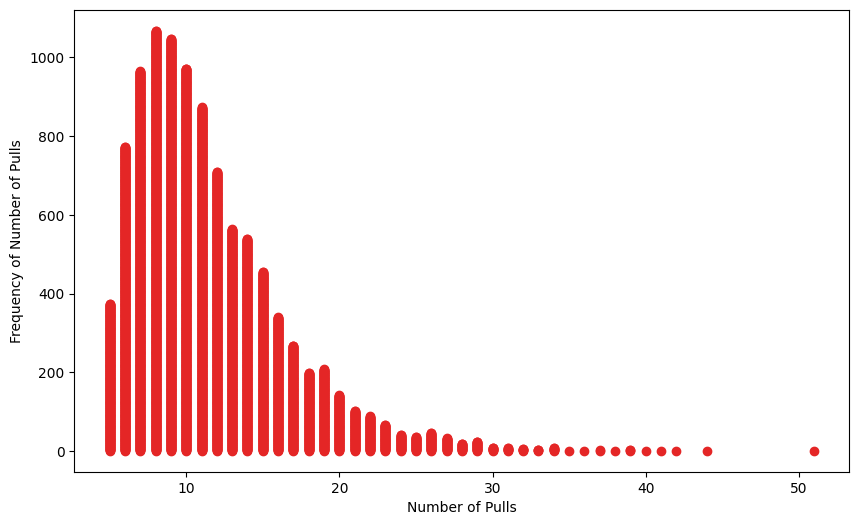

In [99]:
#creating visualization of frequency distribution to a Stacked Dot Plot

x_values = []
y_values = []

for _, row in frequency_df.iterrows():
  pulls = row["pulls"]
  frequency = row["count"]

  x_values.extend([pulls] * frequency)
  y_values.extend(range(1, frequency + 1))

plt.figure(figsize = (10, 6))
plt.scatter(x_values, y_values, color = ["#E42626"])

plt.xlabel("Number of Pulls")
plt.ylabel("Frequency of Number of Pulls")

plt.show()

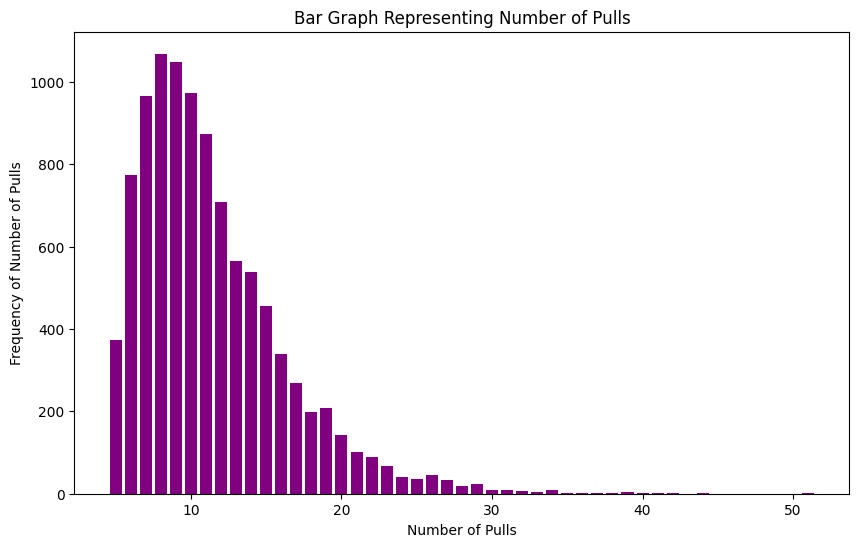

In [100]:
#Creating a bar graph using the .bar() function

plt.figure(figsize = (10, 6))
plt.bar(x_values, y_values, color = "purple")

plt.xlabel("Number of Pulls")
plt.ylabel("Frequency of Number of Pulls")
plt.title("Bar Graph Representing Number of Pulls")

plt.show()

In [107]:
#Metrics of Distrubution
#SOURCES:
'''
https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.rename.html$0
https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.drop.html$0
https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.describe.html$0
'''

metrics = frequency_df.describe().rename({"50%": "median"}).drop(["count", "min", "max"])
print(metrics)

            pulls       count
mean    24.700000  250.000000
std     12.077103  349.034933
25%     14.750000    3.750000
median  24.500000   43.500000
75%     34.250000  394.250000
